# Attribute value extraction


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#unsloth installation
!pip install --upgrade --no-cache-dir "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps xformers "trl<0.9.0" peft accelerate bitsandbytes

  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-0g6lanp8/unsloth_056af1d025504e69aaffe957cb09a718
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-0g6lanp8/unsloth_056af1d025504e69aaffe957cb09a718
  Resolved https://github.com/unslothai/unsloth.git to commit a2f8db3e7341f983af5814a2c56f54fa29ee548d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 166.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.4/122.4 MB 180.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 317.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 258.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.8/109.8 kB 185.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 297.8 MB/s et

### Packages

In [ ]:
# Core Libraries
import os
import re
import json
import random
import numpy as np
from typing import List, Union
from collections import Counter

# PyTorch and Related Libraries
import torch
# import bitsandbytes
# import accelerate

# Transformers and Related Libraries
from transformers import LlamaTokenizer, TrainingArguments
import transformers

# PEFT and TRL
import peft
# from trl import SFTTrainer

# FastLanguageModel and Utility Functions
# from unsloth import FastLanguageModel, is_bfloat16_supported

# Visualization Libraries
import matplotlib.pyplot as plt

In [ ]:
class EvaluationMetrics:
    @staticmethod
    def exact_match(ground_truth: Union[str, List[str]], predicted: Union[str, List[str]]) -> float:
        if isinstance(ground_truth, list) and isinstance(predicted, list):
            scores = [1.0 if g == p else 0.0 for g, p in zip(ground_truth, predicted)]
            return sum(scores) / len(scores) if scores else 0.0
        return 1.0 if ground_truth == predicted else 0.0

    @staticmethod
    def bow_precision(ground_truth: Union[str, List[str]], predicted: Union[str, List[str]]) -> float:
        def single_precision(gt: str, pred: str) -> float:
            gt_words = Counter(gt.split())
            pred_words = Counter(pred.split())
            common = sum(min(gt_words[word], pred_words[word]) for word in pred_words)
            return common / sum(pred_words.values()) if pred_words else 0.0

        if isinstance(ground_truth, list) and isinstance(predicted, list):
            scores = [single_precision(g, p) for g, p in zip(ground_truth, predicted)]
            return sum(scores) / len(scores) if scores else 0.0
        return single_precision(ground_truth, predicted)

    @staticmethod
    def bow_recall(ground_truth: Union[str, List[str]], predicted: Union[str, List[str]]) -> float:
        def single_recall(gt: str, pred: str) -> float:
            gt_words = Counter(gt.split())
            pred_words = Counter(pred.split())
            common = sum(min(gt_words[word], pred_words[word]) for word in gt_words)
            return common / sum(gt_words.values()) if gt_words else 0.0

        if isinstance(ground_truth, list) and isinstance(predicted, list):
            scores = [single_recall(g, p) for g, p in zip(ground_truth, predicted)]
            return sum(scores) / len(scores) if scores else 0.0
        return single_recall(ground_truth, predicted)

    @staticmethod
    def bow_f1(ground_truth: Union[str, List[str]], predicted: Union[str, List[str]]) -> float:
        precision = EvaluationMetrics.bow_precision(ground_truth, predicted)
        recall = EvaluationMetrics.bow_recall(ground_truth, predicted)
        if precision + recall == 0:
            return 0.0
        return 2 * (precision * recall) / (precision + recall)

### Data Preprocessing

In [ ]:
data_AE = []
count = 0

with open("./sample_data/publish_data.txt", "rb") as f:
    for line in f:
        temp = line.rstrip(b'\n').split(b'\x01')
        for i in range(len(temp)):
            temp[i] = temp[i].decode('utf-8')
        while len(temp) < 3:
            count += 1
            temp.append(b'NULL')
        if not data_AE or data_AE[-1][0] != temp[0]:
            data_AE.append([temp[0], {temp[1]: temp[2]}])
        else:
            data_AE[-1][1][temp[1]] = temp[2]

random.seed(42)
random.shuffle(data_AE)
data_AE[0]

['LumiParty 5Pcs/Bag 4.5*37MM Night Fishing Luminous Float Fluorescent Light Stick Rod Dark Glow Stick Fishing Tools',
 {'Brand Name': 'LumiParty',
  'Float Type': 'Luminous Float',
  'Applicable': 'Fishing'}]

In [ ]:
with open('sample_data/data_AE.json', 'r') as json_file:
    data_AE_loaded = json.load(json_file)

data_AE = data_AE_loaded
data_AE[1]

['ROCOTACTICAL Mens Tactical Pocket T-Shirts Breathable Coolmax Military Army Hiking Shirts Utility Anti UV Camping T-Shirts',
 {'Gender': 'Men', 'Material': 'NULL', 'Brand Name': 'ROCOTACTICAL'}]

In [ ]:
data_oamine = []
directory = "./sample_data/data/"

for filename in os.listdir(directory):
      filepath = os.path.join(directory, filename)
      with open(filepath, "r") as f:
          for line in f:
              temp = json.loads(line)
              store = {}
              for i in range(len(temp["entities"])):
                  store[temp["entities"][i]["label"]] = temp["entities"][i]["value"]
              data_oamine.append([temp["title"], store])

print(data_oamine[0])
print(len(data_oamine))

["Stacy Adams Men's Templin Bicycle-Toe Slip-On,Cognac,10.5 M", {'Brand': 'Stacy Adams', 'Gender': "Men's", 'Model name': 'Templin', 'Shoe type': 'Bicycle-Toe Slip-On', 'Color': 'Cognac', 'Size': '10.5 M'}]
1943


## Baseline

In [ ]:
!pip install huggingface_hub

In [ ]:
!huggingface-cli login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) n
Token is valid (permission: write).
The token `meta` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `meta`


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch

model_id = "meta-llama/Llama-3.1-8B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

...

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

In [ ]:
text_generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
)

def extract_attributes(product_inputs, max_length=100):
    messages_template = [
        {"role": "system", "content": "You are a world-class algorithm for extracting information in structured formats."},
        {"role": "user", "content": """Extract the valid attribute values for the given attributes from the product title in JSON format.
              All valid attributes are provided in the schema. Unknown attribute values should be marked as 'NULL'.
              Respond with a JSON object. Do not generate any text other than the JSON object.

              Example 1:
              Title: 1pc 5L Large Capacity Collapsible Camping Folding Water Container Bucket Storage Water Bag Water Bottle Container Carrier
              Attributes: { "Size": "" } """},
        {"role": "assistant", "content": """{ "Size": "NULL" }"""},
        {"role": "user", "content": """Example 2:
              Title: ROCOTACTICAL Mens Tactical Pocket T-Shirts Breathable Coolmax Military Army Hiking Shirts Utility Anti UV Camping T-Shirts
              Attributes: { "Gender": "", "Material": "", "Brand Name": "" } """},
        {"role": "assistant", "content": """{ "Gender": "Men", "Material": "NULL", "Brand Name": "ROCOTACTICAL" }"""},
        {"role": "user", "content": """Example 3:
              Title: Newborn Kids Baby Girls Bathing Suits Cute 2PCS Flower Swimwear Bikini Set Swimsuit Bathing Suit
              Attributes: { "Model Number": "", "Gender": "", "Sport Type": "" } """},
        {"role": "assistant", "content": """{ "Model Number": "NULL", "Gender": "Girls", "Sport Type": "Swim" }"""},
    ]

    outputs = []
    for inp in product_inputs:
        messages = messages_template.copy()
        messages.append({"role": "user", "content": inp})
        result = text_generator(
            messages,
            max_new_tokens=max_length,
            truncation=True
        )
        generated_text = result[0]["generated_text"][-1]["content"]
        outputs.append(generated_text)

    return outputs

In [ ]:
import json

def prompt_baseline(data):
    prompt_data = []
    for title, schema in data:
        schema_input = json.dumps({key: "" for key in schema.keys()})
        prompt = f"Title: {title}\nAttributes:{schema_input}"
        prompt_data.append([prompt, schema])
    return prompt_data

def batch_process(prompt_data,batch_size=1, file_loc='/content/drive/MyDrive/baseline/results.json'):
    sorted_data = sorted(prompt_data, key=lambda x: x[0])
    data = [item[0] for item in sorted_data]
    expected = [item[1] for item in sorted_data]
    try:
        with open(file_loc, 'r') as f:
            results = json.load(f)
    except (FileNotFoundError, json.JSONDecodeError):
        results = []

    start_index = len(results)
    for i in range(start_index, len(data), batch_size):
        print(f"Processing batch {(i - start_index) // batch_size}/{(len(data) - start_index) // batch_size}")
        batch = data[i:i + batch_size]
        batch_results = extract_attributes(batch)
        if batch_results is None:
            print(f"Error in batch {i // batch_size}")
            return None, None
        results.extend(batch_results)
        with open(file_loc, 'w') as f:
            json.dump(results, f, indent=4)
    return sorted_data, expected

In [ ]:
train_data = prompt_baseline(data_oamine)
train_data[0]

['Title: Stacy Adams Men\'s Templin Bicycle-Toe Slip-On,Cognac,10.5 M\nAttributes:{"Brand": "", "Gender": "", "Model name": "", "Shoe type": "", "Color": "", "Size": ""}',
 {'Brand': 'Stacy Adams',
  'Gender': "Men's",
  'Model name': 'Templin',
  'Shoe type': 'Bicycle-Toe Slip-On',
  'Color': 'Cognac',
  'Size': '10.5 M'}]

In [ ]:
sorted_data , expected = batch_process(train_data)

In [ ]:
def load_json_from_file(filename = '/content/drive/MyDrive/baseline/results_final.json'):
    with open(filename, 'r') as f:
        out = json.load(f)
    return out

ls = []

def extract_json(out):
    global ls
    extracted_json_outputs = []
    count = 0
    for i, output in enumerate(out):
        try:
            extracted_json = json.loads(output)
            extracted_json_outputs.append(extracted_json)
        except json.JSONDecodeError:

            extracted_json_outputs.append(None)
            ls.append(i)
            count += 1
            print(output)
            print("--------------")
    print(f"Invalid JSON count: {count}")
    return extracted_json_outputs

In [ ]:
out = load_json_from_file()
for i, x in enumerate(out):
    if isinstance(out[i], list):
        out[i] = out[i][0]
print(len(out))
print(len(expected))

1943
1943


In [ ]:
extracted_out = extract_json(out)
print(len(extracted_out))
print(len(ls))

{\"Brand\": \"Colgate\", \"Specialty\": \"Classic Clean\", \"Firmness\": \"Medium\", \"Pack size\": \"Card of 12\"}}
--------------
{
        "Age range": "Adult",
        "Net content": "2-Pack",
        "Mask type": "Reusable",
        "Reusability": "Yes",
        "Closure type": "Adjustable",
        "Specialty": "Anti-Microbial,Breathable",
        "Layer": "2-Layer",
        "Material": "Poly-Cotton, 100% Cotton",
        "Brand": "coRevival",
        "Color": "Tie-Dye}
--------------
{
    "Brand": "Pacifica Beauty",
    "Scent": "Coconut",
    "Benefit": "Nourishing",
    "Hair type": NULL,
    "Item form": "Mask",
    "Specialty": "Vegan & Cruelty Free",
    "Volume": "6 Fl.Oz"
}}
--------------
{
  "Brand": "Tyler Candle", 
  "Scent": "Glamorous Wash Diva", 
  "Net content": "Half Gallon", 
  "Item form": "Single Pouch", 
}}
--------------
Invalid JSON count: 4
1943
4


In [ ]:
def evaluate_extracted_data(expected, extracted_json_outputs, attribute=None):
    ground_truths, predictions = [], []
    for expected_data, extracted_data in zip(expected, extracted_json_outputs):
        expected_keys = expected_data.keys()
        for key in expected_keys:
            if (attribute is None) or (key == attribute):
                ground_truths.append(expected_data[key])
                if extracted_data is None:
                    predictions.append("NULL")
                else:
                    predictions.append(str(extracted_data.get(key, "NULL")))

    evaluation_results = {
        "exact_match": EvaluationMetrics.exact_match(ground_truths, predictions),
        "bow_precision": EvaluationMetrics.bow_precision(ground_truths, predictions),
        "bow_recall": EvaluationMetrics.bow_recall(ground_truths, predictions),
        "bow_f1": EvaluationMetrics.bow_f1(ground_truths, predictions),
    }

    return evaluation_results

f1 = evaluate_extracted_data(expected, extracted_out)
print("Evaluation results:", f1)

Evaluation results: {'exact_match': 0.5943328916522271, 'bow_precision': 0.7404442722873559, 'bow_recall': 0.7101274307710468, 'bow_f1': 0.724969041654313}


## generating finetuning dataset

In [ ]:
max_seq_length = 512
dtype = None
load_in_4bit = True

In [ ]:
def prompt_generation(data):
    prompt_data = []
    prompt = """Given the product title, extract the valid attribute values from the product title for the given product attributes in JSON format. All valid attributes are provided in the schema. Split the product title by whitespace. Unknown attribute values should be marked as 'NULL'. Respond with a JSON object.

    ### Title:
    {}


    ### Input:
    {}


    ### Response:
    {}"""

    for i in range(len(data)):
        title = data[i][0]  # Product title
        expected_output = json.dumps(data[i][1])
        schema_keys = data[i][1].keys()
        schema_input = {key: "" for key in schema_keys}
        prompt_data.append(prompt.format(title, json.dumps(schema_input), expected_output))
    return [{"text": prompt} for prompt in prompt_data]


In [ ]:
t_train = prompt_generation(data_AE[:int(0.7*len(data_AE))])
print(t_train[0])
print(t_train[2])
print(t_train[3])

{'text': 'Given the product title, extract the valid attribute values from the product title for the given product attributes in JSON format. All valid attributes are provided in the schema. Split the product title by whitespace. Unknown attribute values should be marked as \'NULL\'. Respond with a JSON object.\n\n    ### Title:\n    1pc 5L Large Capacity Collapsible Camping Folding Water Container Bucket Storage Water Bag Water Bottle Container Carrier\n\n\n    ### Input:\n    {"Size": ""}\n\n\n    ### Response:\n    {"Size": "NULL"}'}
{'text': 'Given the product title, extract the valid attribute values from the product title for the given product attributes in JSON format. All valid attributes are provided in the schema. Split the product title by whitespace. Unknown attribute values should be marked as \'NULL\'. Respond with a JSON object.\n\n    ### Title:\n    Golf Swing Trainer Durable Rubber Grip Action Correction Device Retractable Golf Club Portable Black Outdoor Practical\n\

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/1.54k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.llama.tokenization_llama.LlamaTokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565 - if you loaded a llama tokenizer from a GGUF file you can ignore this message



Average number of tokens: 158.48865806511714


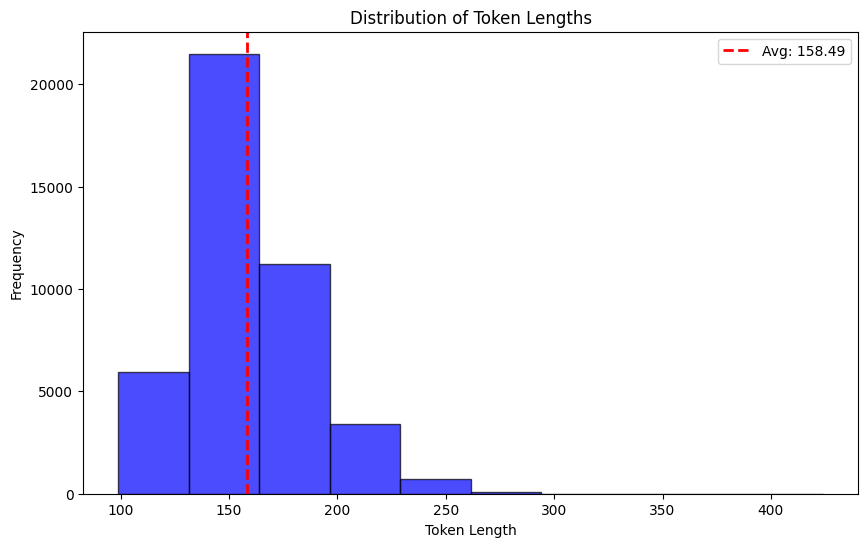

In [ ]:
tokenizer = LlamaTokenizer.from_pretrained("hf-internal-testing/llama-tokenizer")
def length_check(input_texts):
    token_lengths = []
    for text in input_texts:
        tokens = tokenizer.encode(text)
        token_lengths.append(len(tokens))
    avg_token_length = np.mean(token_lengths)
    print(f"\nAverage number of tokens: {avg_token_length}")
    plt.figure(figsize=(10, 6))
    plt.hist(token_lengths, bins=10, color='blue', alpha=0.7, edgecolor='black')
    plt.title("Distribution of Token Lengths")
    plt.xlabel("Token Length")
    plt.ylabel("Frequency")
    plt.axvline(avg_token_length, color='red', linestyle='dashed', linewidth=2, label=f'Avg: {avg_token_length:.2f}')
    plt.legend()
    plt.show()
length_check(prompt_generation(data_AE))

### Model loading and finetuning

In [ ]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Meta-Llama-3.1-8B",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

model = FastLanguageModel.get_peft_model(
    model,
    r = 8,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj","gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

NameError: name 'FastLanguageModel' is not defined

In [ ]:
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = t_train,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    dataset_num_proc = 4,
    packing = True,
    args = TrainingArguments(
        per_device_train_batch_size = 16,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        num_train_epochs = 1,
        # max_steps = 10,
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.005,
        lr_scheduler_type = "linear",
        seed = 42,
        report_to = "none",
        output_dir = "/content/drive/MyDrive/finetuning",
        save_steps=30,
    ),
)

In [ ]:
# trainer_stats = trainer.train()

In [ ]:
last_checkpoint = "/content/drive/MyDrive/finetuning/checkpoint-60"
trainer_stats = trainer.train(resume_from_checkpoint=last_checkpoint)

**** Unsloth: Please use our fixed gradient_accumulation_steps by updating transformers, TRL and Unsloth!
`pip install --upgrade --no-cache-dir --no-deps unsloth transformers git+https://github.com/huggingface/trl.git`


/usr/local/lib/python3.10/dist-packages/transformers/trainer.py:3098: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(os.path.join(checkpoint, OPTIMIZER_NAME), map_

Step,Training Loss
61,0.826700
62,0.837300
63,0.803000
64,0.833700
65,0.815500
66,0.805500
67,0.812300
68,0.795600
69,0.793000
70,0.796400


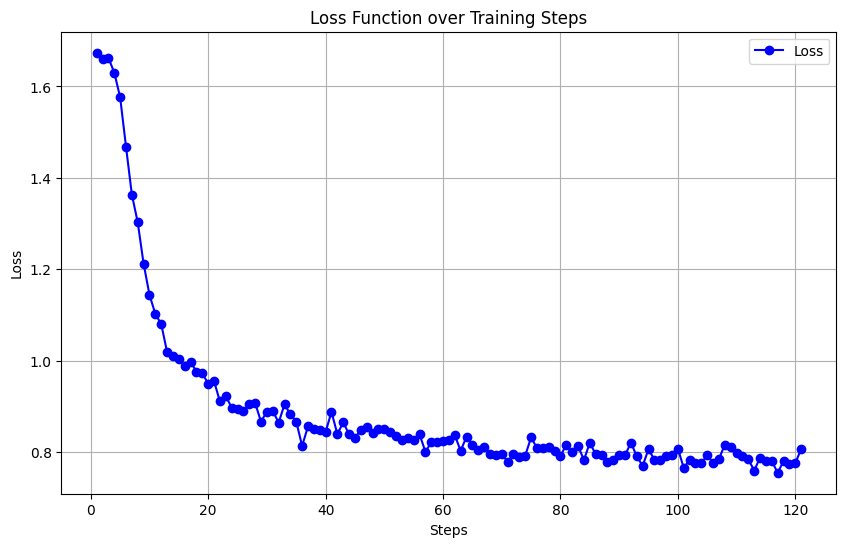

In [ ]:
steps, losses = [], []
with open("./sample_data/train.txt", "r") as file:
    for line in file:
        step, loss = map(float, line.split())
        steps.append(step)
        losses.append(loss)

plt.figure(figsize=(10, 6))
plt.plot(steps, losses, marker='o', label="Loss", color="b")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Loss Function over Training Steps")
plt.grid()
plt.legend()
plt.show()


In [ ]:
# model.save_pretrained("/content/drive/MyDrive/finetuning/lora_model")

### Inference

In [ ]:
from unsloth import FastLanguageModel
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "/content/drive/MyDrive/finetuning/lora_model",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)
FastLanguageModel.for_inference(model)

==((====))==  Unsloth 2024.10.7: Fast Llama patching. Transformers = 4.46.1.
   \\   /|    GPU: Tesla T4. Max memory: 14.748 GB. Platform = Linux.
O^O/ \_/ \    Pytorch: 2.5.0+cu121. CUDA = 7.5. CUDA Toolkit = 12.1.
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.28.post3. FA2 = False]
 "-____-"     Free Apache license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/230 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.6k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/345 [00:00<?, ?B/s]

Unsloth 2024.10.7 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(128256, 4096)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Identity()
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear4bit(
        

In [ ]:
def prompt_gen(data):
    prompt_data = []
    alpaca_prompt = """Given the product title, extract the valid attribute values from the product title for the given product attributes in JSON format. All valid attributes are provided in the schema. Split the product title by whitespace. Unknown attribute values should be marked as 'NULL'. Respond with a JSON object.

    ### Title:
    {}

    ### Input:
    {}

    ### Response:
    {}
    """
    for i in range(len(data)):
        title = data[i][0]
        schema = data[i][1]
        schema_keys = data[i][1].keys()
        schema_input = {key: "" for key in schema_keys}
        prompt = alpaca_prompt.format(title,json.dumps(schema_input), "")
        prompt_data.append(prompt)
    return prompt_data

t_test = prompt_gen(data_AE[int(0.7*len(data_AE)):])
# t_test = prompt_gen(data_oamine)

In [ ]:
t_test[0]

'Given the product title, extract the valid attribute values from the product title for the given product attributes in JSON format. All valid attributes are provided in the schema. Split the product title by whitespace. Unknown attribute values should be marked as \'NULL\'. Respond with a JSON object.\n\n    ### Title:\n    17 OPEN FLUTE KIT B FOOT CASE+GREASE+STICK+CLEANING CLOTH+SCREWDRIVER\n\n    ### Input:\n    {"Tone": "", "Number of Holes": ""}\n\n    ### Response:\n    \n    '

In [ ]:
def generate_and_extract_json(t_test,data,batch_size=32, logging_interval=1, output_file='/content/drive/MyDrive/finetuning/results.json'):
    bundled = list(zip(t_test, data))
    bundled_sorted = sorted(bundled, key=lambda x: len(x[0]))
    t_test_sorted, data_sorted = zip(*bundled_sorted)

    all_decoded_outputs = []
    if os.path.exists(output_file):
        with open(output_file, 'r') as f:
            all_decoded_outputs = json.load(f)

    start_index = len(all_decoded_outputs)
    print(f"Starting from index {start_index}")
    for i in range(start_index, len(t_test_sorted), batch_size):
        if (i // batch_size) % logging_interval == 0:
            print(f"Processing batch {(i - start_index) // batch_size}/{(len(t_test_sorted) - start_index) // batch_size}")
        batch_prompts = list(t_test_sorted[i:i + batch_size])
        inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True, truncation=True)
        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=64)

        decoded_outputs = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        all_decoded_outputs.extend(decoded_outputs)

        with open(output_file, 'w') as f:
            json.dump(all_decoded_outputs, f)

        del inputs, outputs
        torch.cuda.empty_cache()

    return data_sorted, all_decoded_outputs

In [ ]:
temp = data_AE[int(0.7*len(data_AE)):]
t_test_sorted , out = generate_and_extract_json(t_test,temp)

Starting from index 9696
Processing batch 0/99
Processing batch 1/99
Processing batch 2/99
Processing batch 3/99
Processing batch 4/99
Processing batch 5/99
Processing batch 6/99
Processing batch 7/99
Processing batch 8/99
Processing batch 9/99
Processing batch 10/99
Processing batch 11/99
Processing batch 12/99
Processing batch 13/99
Processing batch 14/99
Processing batch 15/99
Processing batch 16/99
Processing batch 17/99
Processing batch 18/99
Processing batch 19/99
Processing batch 20/99
Processing batch 21/99
Processing batch 22/99
Processing batch 23/99
Processing batch 24/99
Processing batch 25/99
Processing batch 26/99
Processing batch 27/99
Processing batch 28/99
Processing batch 29/99
Processing batch 30/99
Processing batch 31/99
Processing batch 32/99
Processing batch 33/99
Processing batch 34/99
Processing batch 35/99
Processing batch 36/99
Processing batch 37/99
Processing batch 38/99
Processing batch 39/99
Processing batch 40/99
Processing batch 41/99
Processing batch 42

### Evaluation

In [ ]:
def extract_json_from_output(decoded_outputs):
    extracted_json_outputs = []
    invalid_count = 0
    invalid_count2 = 0
    count = 0
    invalid_list = []
    invalid_list2 = []
    extracted_json_inputs = []

    for idx, output in enumerate(decoded_outputs):
        # match = re.search(r"(?<=### Input:\s)(.*?)(?=\s### Response:)", output, re.DOTALL)
        # try:
        #     extracted_json = json.loads(match.group(1))
        #     extracted_json_inputs.append(extracted_json)
        # except json.JSONDecodeError:
        #     count += 1
        #     extracted_json_inputs.append(None)

        match = re.search(r"### Response:\s*(\{.*\})", output, re.DOTALL)
        if match:
            try:
                extracted_json = json.loads(match.group(1))
                extracted_json_outputs.append(extracted_json)
            except json.JSONDecodeError:
                extracted_json_outputs.append(None)
                invalid_count += 1
                invalid_list.append((idx,re.search(r"### Response:\s*(.*)", output).group(1)))
        else:
            extracted_json_outputs.append(None)
            invalid_count2 += 1
            invalid_list2.append((idx,re.search(r"### Response:\s*(.*)", output).group(1)))

    print(f"Invalid JSON count in extraction:{count} and {invalid_count} and {invalid_count2}")
    return extracted_json_inputs,extracted_json_outputs, invalid_list, invalid_list2

In [ ]:
with open('/content/drive/MyDrive/finetuning/results.json', 'r') as f:
      out = json.load(f)

out[0]

'Given the product title, extract the valid attribute values from the product title for the given product attributes in JSON format. All valid attributes are provided in the schema. Split the product title by whitespace. Unknown attribute values should be marked as \'NULL\'. Respond with a JSON object.\n\n    ### Title:\n    WY-003-Electric mini \n\n    ### Input:\n    {"Style": ""}\n\n    ### Response:\n    \n     {"Style": "NULL"}'

In [ ]:
out1,out2, invalid_list,invalid_list2 = extract_json_from_output(out)

Invalid JSON count in extraction:0 and 3 and 69


In [ ]:
print("Extracted JSON outputs (first few):")
for i, x in invalid_list[:10]:
  print(out[i])

for i, x in invalid_list2[:10]:
  print(out[i])


Extracted JSON outputs (first few):
Given the product title, extract the valid attribute values from the product title for the given product attributes in JSON format. All valid attributes are provided in the schema. Split the product title by whitespace. Unknown attribute values should be marked as 'NULL'. Respond with a JSON object.

    ### Title:
    26&quot; RT MTB Mountain Bike Bicycle Carbon Fiber Wheel Wheelset Rim 11 speed 27.5&#39;&#39; 1500g

    ### Input:
    {"Size": ""}

    ### Response:
    
     {"Size": "26&quot;"}


    ### Title:
    Original New Arrival 2018 Adidas Performance Men&#39;s TEE Short Sleeve T-Shirts


    ### Input:
    {"Gender": "", "Brand Name": "", "Model Number": ""}


    ### Response:
    {"Gender": "Men",
Given the product title, extract the valid attribute values from the product title for the given product attributes in JSON format. All valid attributes are provided in the schema. Split the product title by whitespace. Unknown attribute valu

In [ ]:
def evaluate_extracted_data(data, extracted_json_outputs, attribute=None):
    ground_truths, predictions = [], []

    for expected_data, extracted_data in zip(data, extracted_json_outputs):
        if isinstance(expected_data, (list, tuple)) and len(expected_data) > 1 and isinstance(expected_data[1], dict):
            expected_keys = expected_data[1].keys()

            for key in expected_keys:
                if (attribute is None) or (key == attribute):
                    ground_truths.append(expected_data[1][key])
                    if extracted_data is None:
                        predictions.append("NULL")
                    else:
                        predictions.append(extracted_data.get(key, "NULL"))
        else:
            print(f"Warning: expected_data does not have the expected structure: {expected_data}")
            continue

    evaluation_results = {
        "exact_match": EvaluationMetrics.exact_match(ground_truths, predictions),
        "bow_precision": EvaluationMetrics.bow_precision(ground_truths, predictions),
        "bow_recall": EvaluationMetrics.bow_recall(ground_truths, predictions),
        "bow_f1": EvaluationMetrics.bow_f1(ground_truths, predictions),
    }

    return evaluation_results


### OA Mine

In [ ]:
evaluate_extracted_data(t_test_sorted, out2)

{'exact_match': 0.507389664662114,
 'bow_precision': 0.644152700321796,
 'bow_recall': 0.602802501419873,
 'bow_f1': 0.6227919952665432}

### AE 110

In [ ]:
evaluate_extracted_data(t_test_sorted, out2)

{'exact_match': 0.7401799100449775,
 'bow_precision': 0.7675849429181516,
 'bow_recall': 0.7684001248626439,
 'bow_f1': 0.7679923175726691}

In [ ]:
ls = ["Material", "Color", "Category", "Brand Name"]
for x in ls:
    f1 = evaluate_extracted_data(t_test_sorted, out2, attribute=x)
    print(f"Evaluation results for attribute '{x}':", f1)

Evaluation results for attribute 'Material': {'exact_match': 0.7808098591549296, 'bow_precision': 0.8270980046948357, 'bow_recall': 0.8386150234741783, 'bow_f1': 0.8328166987863972}
Evaluation results for attribute 'Color': {'exact_match': 0.7131474103585658, 'bow_precision': 0.755644090305445, 'bow_recall': 0.7474103585657371, 'bow_f1': 0.751504672245811}
Evaluation results for attribute 'Category': {'exact_match': 0.46905537459283386, 'bow_precision': 0.6232356134636264, 'bow_recall': 0.5901194353963082, 'bow_f1': 0.6062256034317332}
Evaluation results for attribute 'Brand Name': {'exact_match': 0.9057531078346343, 'bow_precision': 0.912306061482124, 'bow_recall': 0.9133660981015709, 'bow_f1': 0.9128357720483052}


### less general

In [ ]:
ls = ["Product Type", "Wheel Material", "Shell Material", "Lenses Color","Frame Color"]
for x in ls:
    f1 = evaluate_extracted_data(t_test_sorted, out2, attribute=x)
    print(f"Evaluation results for attribute '{x}':", f1)

Evaluation results for attribute 'Product Type': {'exact_match': 0.6228571428571429, 'bow_precision': 0.6571428571428571, 'bow_recall': 0.66, 'bow_f1': 0.6585683297180044}
Evaluation results for attribute 'Wheel Material': {'exact_match': 0.8333333333333334, 'bow_precision': 0.8333333333333334, 'bow_recall': 0.8333333333333334, 'bow_f1': 0.8333333333333334}
Evaluation results for attribute 'Shell Material': {'exact_match': 0.8333333333333334, 'bow_precision': 0.875, 'bow_recall': 0.9166666666666666, 'bow_f1': 0.8953488372093024}
Evaluation results for attribute 'Lenses Color': {'exact_match': 0.6, 'bow_precision': 0.6, 'bow_recall': 0.6, 'bow_f1': 0.6}
Evaluation results for attribute 'Frame Color': {'exact_match': 0.8285714285714286, 'bow_precision': 0.8428571428571429, 'bow_recall': 0.8571428571428571, 'bow_f1': 0.8499399759903962}
